In [1]:
import sys
sys.path.append(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq")

from TCC.utils.constantes import *
import matplotlib.pyplot as plt

In [10]:
df_btc_price = pd.read_csv(rf"raw/price_btc.csv")
df_btc_price['Data_UTC'] = pd.to_datetime(df_btc_price['time'], unit='s', utc=True,).dt.strftime("%Y-%m-%d")

df_target_price =(
    df_periodo
        .merge(df_btc_price[['Data_UTC','close']], how='left', on='Data_UTC')
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        .rename(columns={'close':'btc_price'})
        .query("Data_UTC > '2016-12-31'")
        [['Data_UTC','btc_price']]

)
df_target_price

,Data_UTC,btc_price
1,2017-01-01,996.34775
2,2017-01-02,1015.50275
3,2017-01-03,1032.29750
4,2017-01-04,1130.39975
5,2017-01-05,1005.64250
...,...,...
3131,2025-07-28,118085.05000
3132,2025-07-29,117940.69000
3133,2025-07-30,117815.05000
3134,2025-07-31,115760.52000


## BTC RVI (Relative Volatility Index)
- Indicador técnico que mede a direção da volatilidade calculando o desvio padrão dos preços altos e baixos em uma escala de 0 a 100. Valores acima de 50 indicam volatilidade expansiva (convicção de tendência).

- Fonte: https://br.tradingview.com/support/solutions/43000594684/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)

- A "Profecia Autorrealizável" da Análise Técnica. Num mercado dominado por investidores de retalho e desprovido de fundamentos macroeconómicos claros, a ação do preço era regida quase exclusivamente pela especulação e análise gráfica. Hipotetiza-se que o RVI possuía alta significância estatística e poder preditivo, pois sinalizações de expansão de volatilidade atuavam como gatilhos para o comportamento de manada (herding behavior) e FOMO (Fear Of Missing Out), gerando momentum inercial nos retornos do Bitcoin.

## Hipótese 2: Era Institucional (Pós-2020)

- Perda de Eficácia por Eficiência de Mercado. Com a entrada de High Frequency Trading (HFT) e arbitragem institucional, o mercado tornou-se mais eficiente na incorporação de informações técnicas. Hipotetiza-se que indicadores simples como o RVI perderam capacidade preditiva defasada (Granger) sobre o preço. Neste novo regime, a volatilidade do Bitcoin deixa de ser apenas um fenômeno endógeno (técnico) e passa a ser uma resposta exógena a choques de liquidez global (Juros/Dólar), tornando o oscilador técnico menos relevante isoladamente.

### TRATAMENTO
- Como ele oscila entre 0 e 100 (sua média é ~52), ele já possui limites definidos, o que evita a necessidade de Log. No entanto, para modelos de séries temporais (como VAR), o valor absoluto (ex: 55) importa menos do que a mudança de estado (se a volatilidade está acelerando ou desacelerando). Por isso, a Primeira Diferença é o tratamento ideal.

In [20]:
df_btc_rvi =(
    df_periodo
        .merge(df_btc_price, how='left', on='Data_UTC')
        .assign(rvi_diff = lambda df: df['RVI'].diff())
        .query("Data_UTC > '2016-12-31'")
        .rename(columns={'RVI':'rvi_close'})
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']).dt.strftime("%Y-%m-%d"))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        [['Data_UTC','rvi_close','rvi_diff']]

)
df_btc_rvi


,Data_UTC,rvi_close,rvi_diff
1,2017-01-01,69.100895,4.586413
2,2017-01-02,73.568288,4.467393
3,2017-01-03,77.466466,3.898178
4,2017-01-04,81.752794,4.286328
5,2017-01-05,68.620331,-13.132464
...,...,...,...
3131,2025-07-28,54.333251,-4.828541
3132,2025-07-29,49.661577,-4.671673
3133,2025-07-30,45.401673,-4.259905
3134,2025-07-31,39.953438,-5.448235


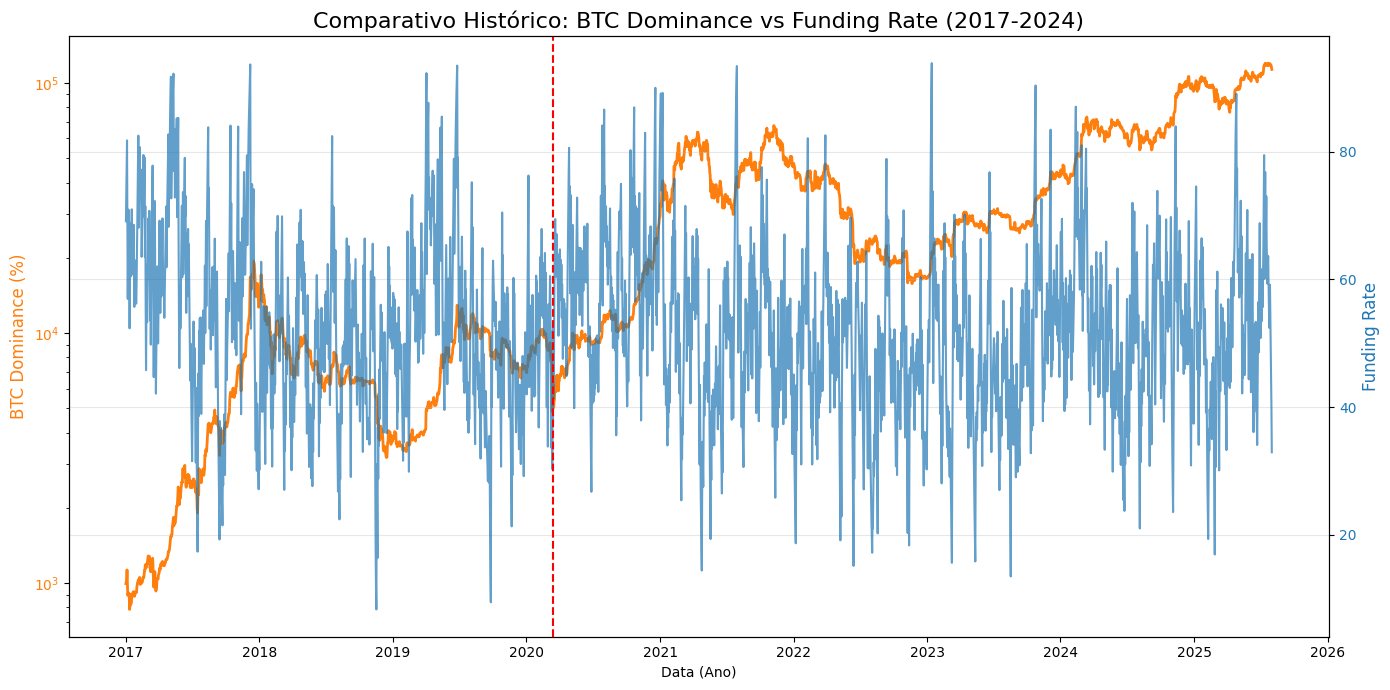

In [21]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Dominance (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Dominance (%)', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('Funding Rate', color=color, fontsize=12)
ax2.plot(df_btc_rvi['Data_UTC'], df_btc_rvi['rvi_close'], color=color, label='Funding Rate', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs Funding Rate (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## Funding Rate (Futuros)
- A Funding Rate é o mecanismo que mantém o preço dos contratos futuros perpétuos alinhado ao preço à vista (Spot).
    - Positiva: Os comprados (Longs) pagam os vendidos (Shorts). Indica que a maioria está apostando na alta (otimismo/ganância).
    - Negativa: Os vendidos pagam os comprados. Indica que a maioria está apostando na queda (pessimismo/medo).

- Fonte: https://academy.santiment.net/metrics/funding-rates-aggregated/#definition

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
- O Termómetro da Alavancagem Direcional ("BitMEX Era"). O mercado de derivativos era dominado por especuladores direcionais altamente alavancados (100x). Hipotetiza-se que a Funding Rate possuía alto poder preditivo sobre o preço, funcionando como um indicador de "sobreaquecimento". Taxas excessivamente positivas antecipavam Long Squeezes (quedas abruptas por liquidação em cascata), enquanto taxas negativas sinalizavam fundos locais. A causalidade era direta: o excesso de otimismo (Funding alto) causava a correção do preço.

## Hipótese 2: Era Institucional (Pós-2020)
- Arbitragem de Taxas e Eficiência (Cash & Carry). Com a entrada de mesas de arbitragem e Market Makers sofisticados, a Funding Rate passou a ser explorada para estratégias de Delta Neutral (comprar Spot, vender Futuro para capturar a taxa). Hipotetiza-se que a capacidade preditiva direcional da Funding Rate diminuiu significativamente. Neste regime, taxas altas atraem capital de arbitragem que vende o futuro e compra o à vista, amortecendo os movimentos extremos e reduzindo a correlação direta entre a taxa de financiamento e a tendência futura do preço.

### TRATAMENTO
- Primeira Diferença (Diff)
- Justificativa: Embora a taxa oscile em torno de zero, a diferença captura a mudança na agressividade da alavancagem (aceleração do otimismo ou do medo). Para modelos VAR, remover a autocorrelação da taxa em nível é essencial.

In [16]:
df_funding_cexs = pd.read_csv(r"raw/2017_fundingRateCEXs.csv")

# Tratamento Inicial
df_funding_tratado = (
    df_funding_cexs
    .assign(Data_UTC = lambda df: pd.to_datetime(df['Date']).dt.strftime("%Y-%m-%d"))
    .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
    
    # 1. Média entre Exchanges (Robustez)
    # O parametro numeric_only=True evita erros se houver colunas de texto perdidas
    # O pandas ignora NaNs na média automaticamente (ex: se só tem BitMEX em 2016, usa só BitMEX)
    .assign(total_funding_rate_btc = lambda df: df[[
        'BitMEX Funding Rate', 
        'Binance Funding Rate (USDT)',
        'DyDx Exchange Funding Rates', 
        'Deribit Exchange Funding Rates'
    ]].mean(axis=1, numeric_only=True),
    funding_rate_diff_btc = lambda df: df['total_funding_rate_btc'].diff()
    )

    .query("Data_UTC > '2016-12-31'")
    [['Data_UTC', 'total_funding_rate_btc', 'funding_rate_diff_btc']] # Seleciona apenas o necessário
)

df_funding_tratado

,Data_UTC,total_funding_rate_btc,funding_rate_diff_btc
232,2017-01-01,0.001116,0.001537
233,2017-01-02,0.001892,0.000776
234,2017-01-03,0.001352,-0.000540
235,2017-01-04,0.001414,0.000062
236,2017-01-05,0.003750,0.002336
...,...,...,...
3516,2025-12-29,0.000070,0.000020
3517,2025-12-30,0.000055,-0.000015
3518,2025-12-31,0.000057,0.000002
3519,2026-01-01,0.000036,-0.000021


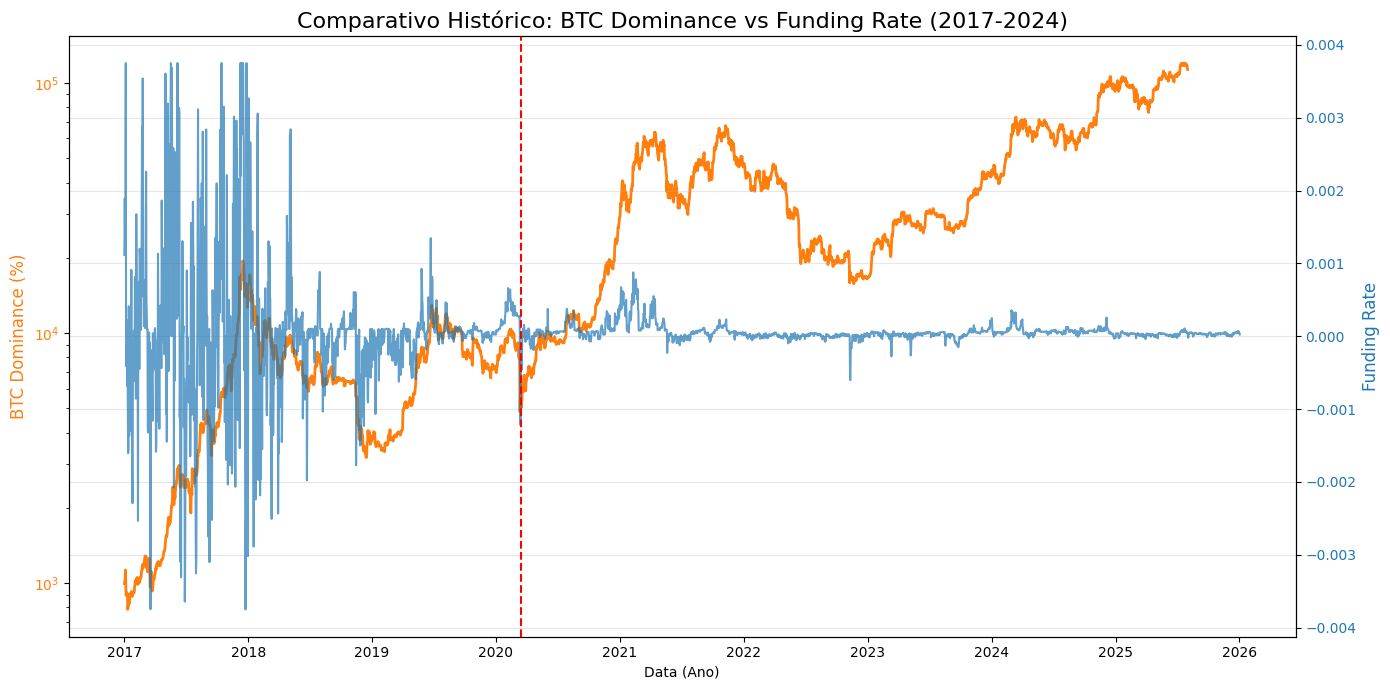

In [17]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Dominance (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Dominance (%)', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('Funding Rate', color=color, fontsize=12)
ax2.plot(df_funding_tratado['Data_UTC'], df_funding_tratado['total_funding_rate_btc'], color=color, label='Funding Rate', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs Funding Rate (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## Miner Net Position Change (Supply Held) BTC
- Mede a quantidade total de Bitcoin mantida em endereços conhecidos de mineradores e pools de mineração.
Para o modelo, utiliza-se a variação (Net Position Change) para identificar acumulação ou distribuição.

- Mineradores são os únicos "vendedores naturais" e compulsórios do mercado (precisam vender para cobrir custos de eletricidade/Hardware). O aumento das reservas indica acumulação (otimismo), enquanto a queda brusca indica "Capitulation" (medo/necessidade de caixa).
- Fonte: https://newhedge.io/bitcoin/miner-reserves

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
- A Hegemonia da Oferta Primária. Neste período, a estrutura de mercado era dominada pela economia interna da rede. Hipotetiza-se que a variação na posição dos mineradores possuía alta causalidade sobre o preço. Num ambiente de liquidez reduzida, vendas massivas de mineradores para cobrir custos operacionais (capitulação) funcionavam como choques de oferta exógenos significativos, incapazes de serem absorvidos rapidamente pela demanda de retalho, provocando quedas abruptas no preço do ativo.

## Hipótese 2: Era Institucional (Pós-2020)
- Diluição do Impacto pela Liquidez Financeira. Com a entrada de veículos de investimento institucional (ETFs, Tesourarias Corporativas) e o aumento exponencial do volume diário de negociação (Trading Volume), a importância relativa da emissão de novos Bitcoins (subsídio de bloco) diminuiu drasticamente. Hipotetiza-se que o fluxo de mineradores perdeu relevância estatística como preditor de preço. A pressão de venda diária da mineração tornou-se marginal frente à profundidade do livro de ofertas institucional, sendo facilmente absorvida sem causar distorções significativas de preço, cedendo protagonismo às variáveis macroeconómicas (VIX, DXY).

### TRATAMENTO
- Precisamos ver a Variação Líquida da Posição (Net Position Change). Se o saldo de ontem era 2.277k e hoje é 2.279k, eles acumularam +2k BTC (bullish). Se caiu, venderam (bearish). O Log-Retorno é perfeito para isso.

In [23]:
df_supply_btc = pd.read_csv(rf"raw/2009_supply_circulation_btc.csv")

df_supply_held_by = (pd.read_csv(rf"raw/2010_supply_held_miners_whales.csv")
                     
                    .merge(df_supply_btc, how='left', on='Date')
                    .assign(Data_UTC = lambda df: pd.to_datetime(df['Date'], utc=True))
                    .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                    .rename(columns={'Total Supply': 'Total_Supply_btc',
                                     'Supply held by Miners': 'supply_held_by_miners_btc'})
                                     
                    [['Data_UTC', 'supply_held_by_miners_btc', 'Total_Supply_btc']]
 
)

df_supply_held_by_miners_btc =(
    df_periodo
        .merge(df_supply_held_by, how='left', on='Data_UTC')
        .assign(miner_net_pos_change = lambda df: np.log(df['supply_held_by_miners_btc']) - np.log(df['supply_held_by_miners_btc'].shift(1)))
        
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        .query("Data_UTC > '2016-12-31'")
        [['Data_UTC','supply_held_by_miners_btc','miner_net_pos_change']]

)
df_supply_held_by_miners_btc

# print_dataframe_info(df_supply_held_by_miners_btc, "Supply Held by Miners - BTC")

,Data_UTC,supply_held_by_miners_btc,miner_net_pos_change
1,2017-01-01,2.279762e+06,0.000938
2,2017-01-02,2.281432e+06,0.000732
3,2017-01-03,2.275769e+06,-0.002485
4,2017-01-04,2.313795e+06,0.016571
5,2017-01-05,2.308724e+06,-0.002194
...,...,...,...
3131,2025-07-28,1.700392e+06,-0.000576
3132,2025-07-29,1.701050e+06,0.000387
3133,2025-07-30,1.702182e+06,0.000665
3134,2025-07-31,1.699895e+06,-0.001344


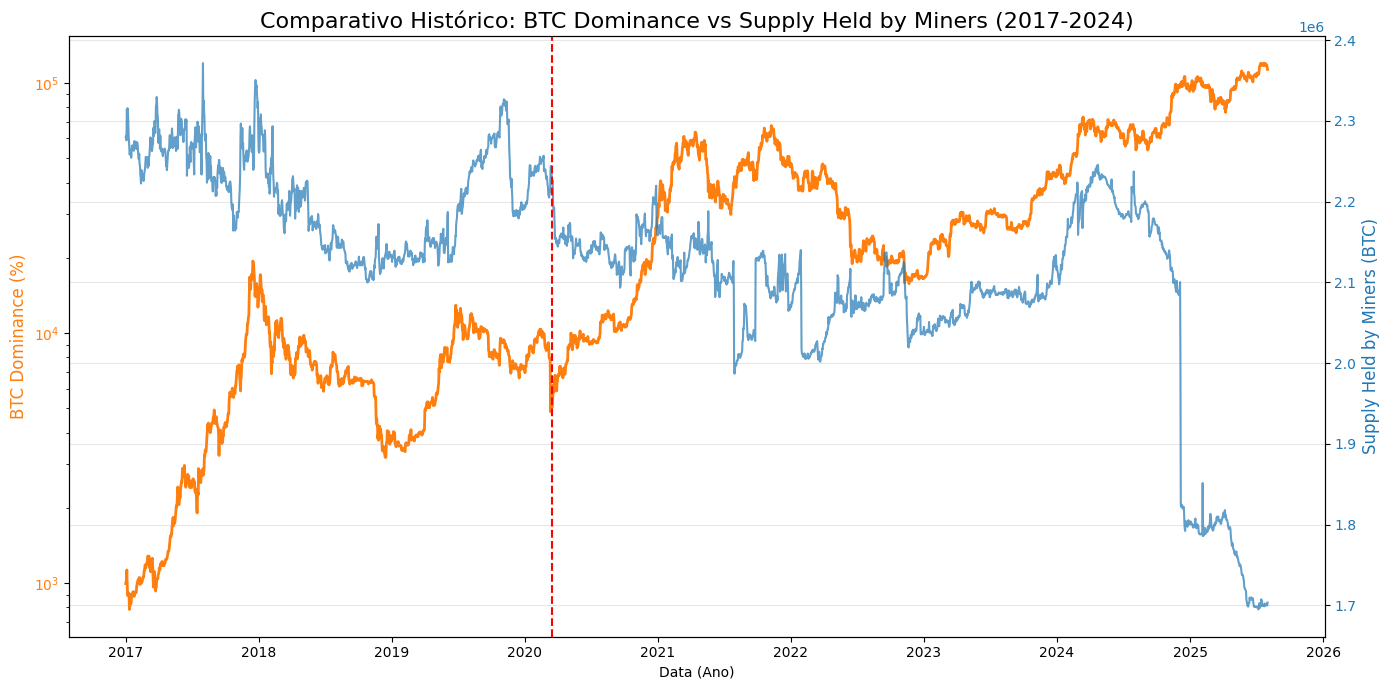

In [24]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Dominance (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Dominance (%)', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('Supply Held by Miners (BTC)', color=color, fontsize=12)
ax2.plot(df_supply_held_by_miners_btc['Data_UTC'], df_supply_held_by_miners_btc['supply_held_by_miners_btc'], color=color, label='Supply Held by Miners', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs Supply Held by Miners (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## Supply on Exchanges (as % of total supply)
- É o "termômetro do medo". Quando participantes enviam ativos para corretoras em massa, a intenção primária é vender ou alavancar (short). A métrica captura esses movimentos de manada ("herd behavior") em direção à liquidez das exchanges.

- Proxy de "Demanda por Venda". Não deve ser lida apenas como estoque estático, mas como um indicador de fluxo correlacionado. Picos nessa métrica (podendo atingir correlações de até 20x) sinalizam que múltiplos endereços estão enviando BTC simultaneamente para CEXs/DEXs conhecidas.

- Fonte: https://academy.santiment.net/metrics/supply-on-or-outside-exchanges/

## Hipótese 1: Era Varejo (Pré-2020)
- O Sinal de "Panic Selling" Imediato. Neste período, a infraestrutura de custódia era precária e o comportamento do investidor era de curto prazo. Hipotetiza-se que aumentos na oferta em exchanges (Net Inflows) tinham correlação negativa forte e imediata com o preço. O envio de moedas para corretoras sinalizava intenção de venda iminente ou capitulação do varejo em momentos de volatilidade, atuando como um indicador antecedente de quedas de preço.

## Hipótese 2: Era Institucional (Pós-2020)
- Choque de Oferta e Escassez Estrutural. Com a popularização de soluções de custódia institucional (Coinbase Custody, Fidelity) e a prática de Cold Storage, observou-se uma tendência secular de saída de ativos das exchanges. Hipotetiza-se que a redução desta métrica atua agora como um suporte de preço a médio prazo. A escassez de oferta líquida disponível (Illiquid Supply) amplifica o impacto de choques de demanda (compras de ETFs), favorecendo a apreciação do preço pela mecânica de Supply Shock.

### TRATAMENTO
- Natureza do Dado: É uma porcentagem (Razão) que varia lentamente (tendência secular), mas tem variações diárias que representam o Fluxo Líquido (Net Flow).
- Problema: A série em nível (ex: 15%, 14%) não é estacionária (tem tendência de baixa clara pós-2020).
- **Solução: Usar a Primeira Diferença (Diff).**
- Se o resultado é positivo, houve Inflow (entrada líquida de moedas para venda). Se negativo, houve Outflow (saída para custódia/hold). Isso transforma a variável de "Estoque" para "Fluxo", que é o que impacta o preço no curto prazo.

In [26]:
df_historical_balance = (pd.read_csv(rf"raw/2010_supply_on_exchanges_perc.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['Date'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))


[['Data_UTC',f'Supply on Exchanges (as % of total supply)']]
 
)

df_supply_held_by_miners_btc =(
    df_periodo
        .merge(df_historical_balance, how='left', on='Data_UTC')
        .rename(columns={f'Supply on Exchanges (as % of total supply)': 'supply_on_exchanges_perc_btc'})
        .assign(exchange_supply_diff_btc = lambda df: df['supply_on_exchanges_perc_btc'].diff())
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        .query("Data_UTC > '2016-12-31'")
        [['Data_UTC','supply_on_exchanges_perc_btc','exchange_supply_diff_btc']]

)
df_supply_held_by_miners_btc

# print_dataframe_info(df_historical_balance, "Supply on Exchanges (as % of total supply) - BTC")

,Data_UTC,supply_on_exchanges_perc_btc,exchange_supply_diff_btc
1,2017-01-01,3.402792,0.028501
2,2017-01-02,3.436960,0.034168
3,2017-01-03,3.424486,-0.012473
4,2017-01-04,3.665006,0.240520
5,2017-01-05,3.700899,0.035892
...,...,...,...
3131,2025-07-28,6.155754,-0.013170
3132,2025-07-29,6.154849,-0.000905
3133,2025-07-30,6.156462,0.001612
3134,2025-07-31,6.149945,-0.006516


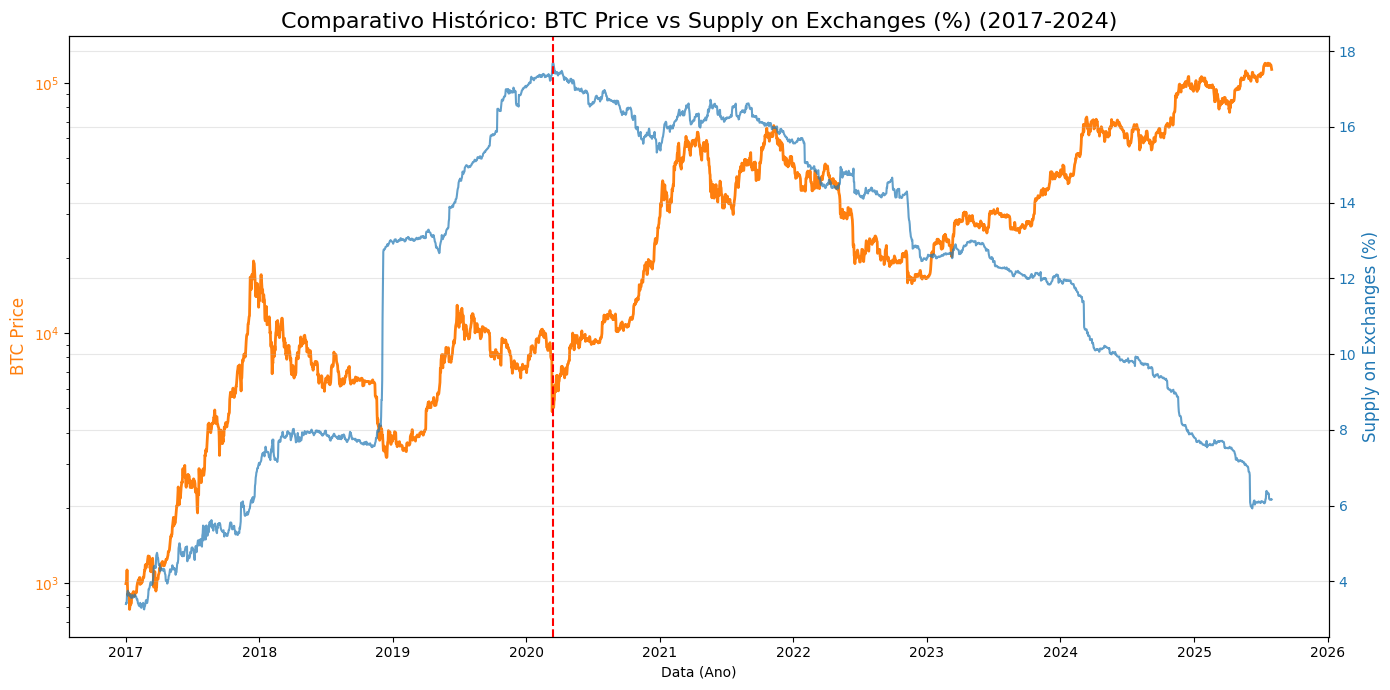

In [27]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('Supply on Exchanges (%)', color=color, fontsize=12)
ax2.plot(df_supply_held_by_miners_btc['Data_UTC'], df_supply_held_by_miners_btc['supply_on_exchanges_perc_btc'], color=color, label='Supply on Exchanges (%)', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Price vs Supply on Exchanges (%) (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## SPX-BTC Rolling Correlation (30d)
- Mede o afastamento relativo entre o preço do Bitcoin e o índice S&P 500. Se o valor aumenta, o Bitcoin está se comportando de forma idiossincrática (única). Se diminui ou fica estável, ele está "acoplado" ao mercado de ações.

- Testa diretamente a hipótese de "Acoplamento Institucional". O Bitcoin deixou de ser um ativo não correlacionado para virar um ativo de "Risco Macro"?

- Fonte: https://academy.santiment.net/metrics/btc-and-s-and-p-500-price-divergence

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
- O Ativo Descorrelacionado (Diversificador). Conforme a literatura clássica (Corbet et al., 2018), o Bitcoin comportava-se como um ativo idiossincrático, isolado dos mercados tradicionais. Hipotetiza-se que a divergência em relação ao S&P 500 era a norma, e não a exceção. Portanto, movimentos do mercado acionário (Risk-On/Risk-Off) tinham baixa ou nula causalidade sobre a formação de preço do Bitcoin, sendo este guiado por fatores endógenos (hacks, regulação, adoção).

## Hipótese 2: Era Institucional (Pós-2020)
- O Bitcoin como "High-Beta Tech Stock". Com a entrada de gestores macro, o Bitcoin passou a ser tratado como um ativo de risco sensível à liquidez global. Hipotetiza-se que a divergência tornou-se um sinal de alerta de risco sistémico específico do setor cripto (ex: Colapso da FTX). Neste regime, espera-se que o Bitcoin siga a tendência do S&P 500 (e especialmente da NASDAQ), reagindo com alavancagem aos mesmos estímulos macroeconómicos.

### TRATAMENTO
- Correlação da média móvel do log-retorno do preco da SP500 e o BTC
- Justificativa: Como a correlação varia entre -1 e 1, ela já é estacionária na maioria das janelas. O nível indica o regime (Risk-on/Risk-off). 

In [29]:
df_sp500 = (pd.read_csv(rf"/Users/baia/Desktop/PYTHON/mba_dsa_usp_esalq/TCC/data/dados_macro/raw/2014_SP500_PRICE.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                         .rename(columns={'close':'spx_price'})


[['Data_UTC','spx_price']]
 
)

df_sp500

df_sp500_btc_divergence_btc =(
    df_periodo
        .merge(df_sp500, how='left', on='Data_UTC')
        .merge(df_btc_price, how='left', on='Data_UTC')

        # Pois o preço do SP500 não está diário, preenche os valores faltantes com o último valor conhecido
        .assign(spx_price = lambda df: df['spx_price'].ffill())
        .assign(btc_log_ret = lambda df: np.log(df['close']/df['close'].shift(1)))
        .assign(spx_log_ret = lambda df: np.log(df['spx_price']/df['spx_price'].shift(1)))

        .assign(btc_spx_corr_30d = lambda df: df['btc_log_ret'].rolling(window=30).corr(df['spx_log_ret']))
        .assign(btc_spx_corr_30d = lambda df: df['btc_spx_corr_30d'].fillna(method='bfill'))     
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))
        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))


        .query("Data_UTC > '2016-12-31'")
        [['Data_UTC','spx_price','btc_log_ret','btc_spx_corr_30d']]

)
df_sp500_btc_divergence_btc
# print_dataframe_info(df_sp500_btc_divergence_btc, "SP500 BTC Divergence - BTC")

/var/folders/h1/_3z4z04x4j17zlfj224w53hr0000gn/T/ipykernel_3418/3108683691.py:26: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  .assign(btc_spx_corr_30d = lambda df: df['btc_spx_corr_30d'].fillna(method='bfill'))


,Data_UTC,spx_price,btc_log_ret,btc_spx_corr_30d
1,2017-01-01,NaN,0.026370,-0.162872
2,2017-01-02,NaN,0.019043,-0.162872
3,2017-01-03,2257.83,0.016403,-0.162872
4,2017-01-04,2270.75,0.090784,-0.162872
5,2017-01-05,2269.00,-0.116945,-0.162872
...,...,...,...,...
3131,2025-07-28,6389.76,-0.011507,0.257894
3132,2025-07-29,6370.87,-0.001223,0.270594
3133,2025-07-30,6362.89,-0.001066,0.332494
3134,2025-07-31,6339.38,-0.017592,0.364173


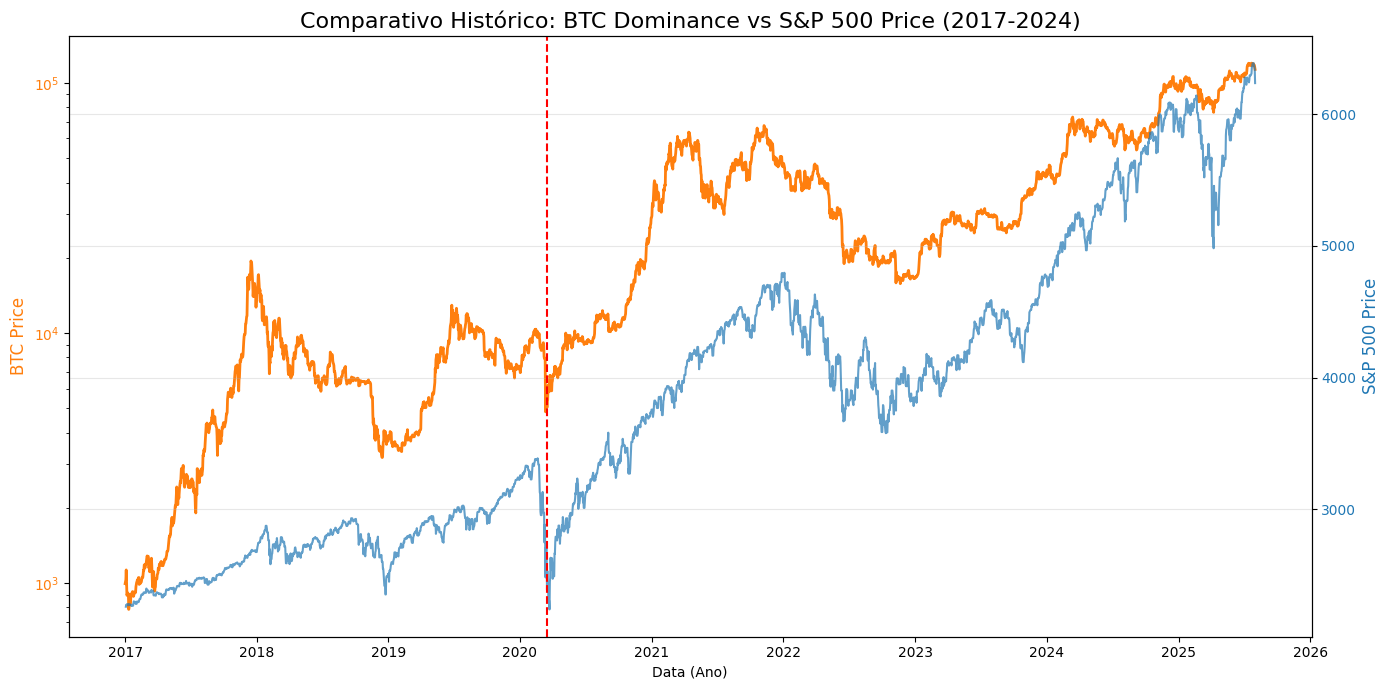

In [31]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('S&P 500 Price', color=color, fontsize=12)
ax2.plot(df_sp500_btc_divergence_btc['Data_UTC'], df_sp500_btc_divergence_btc['spx_price'], color=color, label='SP500', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs S&P 500 Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## Coinbase Premium Index (Manual Ticker)
- diferença percentual entre o preço do Bitcoin na Coinbase Pro (Par BTC/USD) e na Binance (Par BTC/USDT). Indica se o varejo tem mais interesse do que o institucional no bitcoine  vice versa

- A Coinbase é a porta de entrada regulada dos EUA e Institucionais (Tesla, MicroStrategy, Grayscale e ETFs usam a Coinbase). A Binance representa o Varejo Global e especuladores offshore.

- Fonte: https://br.tradingview.com/ (COINBASE:BTCUSD - BINANCE:BTCUSDT)

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Irrelevância do Mercado Spot Americano. O mercado era dominado por derivativos offshore não regulados (BitMEX, Binance Futures), que lideravam a descoberta de preço. Hipotetiza-se que o prêmio na Coinbase (mercado à vista regulado nos EUA) era estatisticamente irrelevante para prever tendências de preço, dado que o volume financeiro real ocorria fora da jurisdição americana.

## Hipótese 2: Era Institucional (Pós-2020)
O Rastro do "Smart Money" Americano. A Coinbase tornou-se a principal porta de entrada para instituições (MicroStrategy, Tesla, ETFs via Coinbase Prime). Hipotetiza-se que um Coinbase Premium positivo (Preço Coinbase > Binance) possui alta causalidade positiva sobre o preço do Bitcoin. Este indicador serve como proxy direto da demanda institucional qualificada, antecipando movimentos de alta sustentável impulsionados por fluxo de caixa real (Spot) em oposição à alavancagem especulativa.

### TRATAMENTO
- Ponto de Atenção: Um prêmio de $50 quando o Bitcoin custava $3.000 (2018) é muito mais relevante percentualmente (1.6%) do que um prêmio de $50 quando o Bitcoin custa $60.000 (0.08%).

- No entanto: Para fins de modelagem de curto prazo (variação diária), o sentimento é capturado pela mudança rápida. Se o prêmio salta de $0 para $50 em um dia, houve uma ordem de compra institucional massiva, independente do preço base.

-  Primeira Diferença (Diff)

- Justificativa: Como os valores oscilam em torno de zero (reversão à média), a diferença captura o "choque de demanda" institucional. Um aumento súbito no diferencial sinaliza entrada agressiva de capital regulado.

In [35]:
df_coinbase_premium = (pd.read_csv(rf"raw/2018_coinbase_premium_index.csv")

                         .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                         .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))

                        .rename(columns={'close': 'cb_premium_usd'}) # Nome mais descritivo que 'close'
                        [['Data_UTC', 'cb_premium_usd']] # Seleciona apenas o necessário
 
)

df_coinbase_premium_diff =(
    df_periodo
        .merge(df_coinbase_premium, how='left', on='Data_UTC')
        .assign(cb_premium_diff_btc = lambda df: df['cb_premium_usd'].diff())
        .assign(Data_UTC = lambda df: pd.to_datetime(df['Data_UTC']))


        .query("Data_UTC > '2019-12-31'")
        [['Data_UTC','cb_premium_usd','cb_premium_diff_btc']]

)
df_coinbase_premium_diff

# print_dataframe_info(df_coinbase_premium, "Coinbase Premium Index - BTC")

,Data_UTC,cb_premium_usd,cb_premium_diff_btc
1096,2020-01-01,-26.52,2.99
1097,2020-01-02,-20.69,5.83
1098,2020-01-03,-10.51,10.18
1099,2020-01-04,-5.48,5.03
1100,2020-01-05,-3.35,2.13
...,...,...,...
3131,2025-07-28,8.27,-41.70
3132,2025-07-29,-17.37,-25.64
3133,2025-07-30,-10.15,7.22
3134,2025-07-31,-2.95,7.20


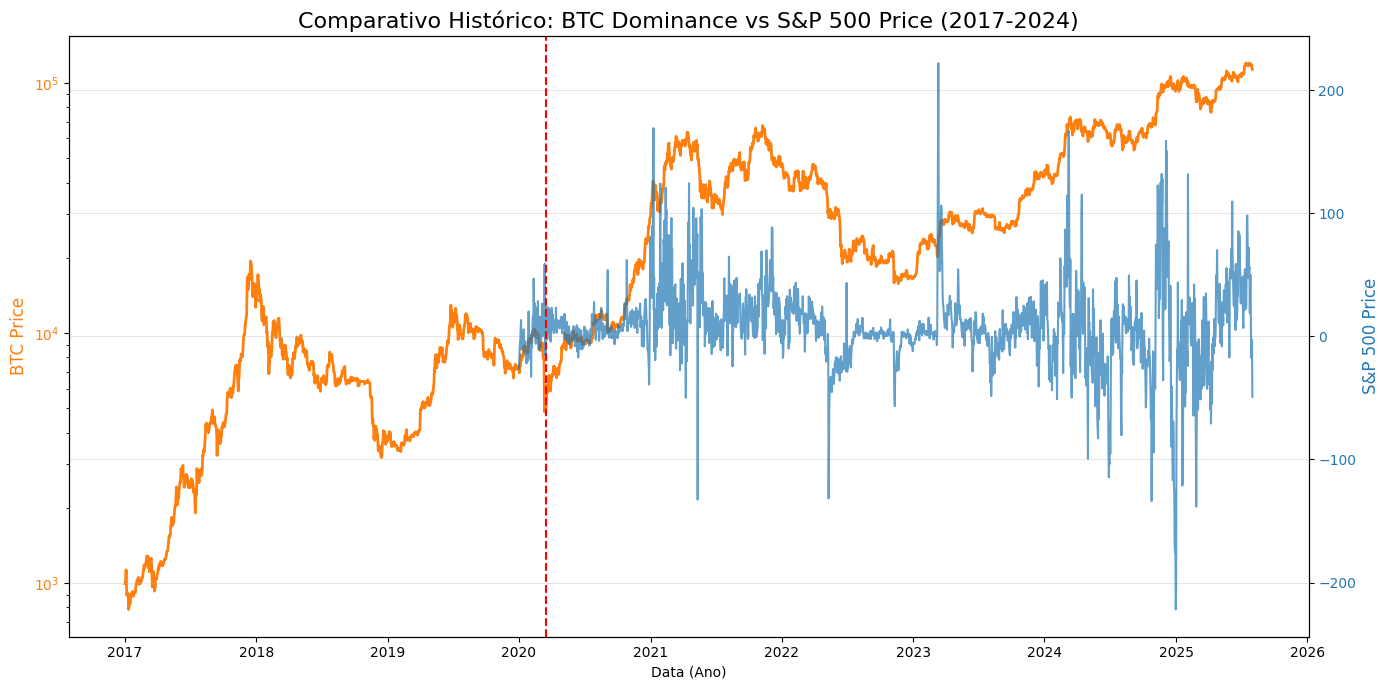

In [36]:
# Configuração do Gráfico
fig, ax1 = plt.figure(figsize=(14, 7)), plt.gca()

# Eixo 1 (Esquerda): BTC Price (Target)
color = 'tab:orange'
ax1.set_xlabel('Data (Ano)')
ax1.set_ylabel('BTC Price', color=color, fontsize=12)
ax1.plot(df_target_price['Data_UTC'], df_target_price['btc_price'], color=color, label='BTC Price', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_yscale('log')

# Eixo 2 (Direita): Variável Macro (ex: S&P 500)
ax2 = ax1.twinx()  # Cria o segundo eixo compartilhando o mesmo X
color = 'tab:blue'
ax2.set_ylabel('S&P 500 Price', color=color, fontsize=12)
ax2.plot(df_coinbase_premium_diff['Data_UTC'], df_coinbase_premium_diff['cb_premium_usd'], color=color, label='SP500', linewidth=1.5, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

# Formatação
plt.title('Comparativo Histórico: BTC Dominance vs S&P 500 Price (2017-2024)', fontsize=16)
plt.grid(True, alpha=0.3)

# Adicionar linha vertical na Quebra de Regime (Março 2020)
plt.axvline(x=pd.to_datetime('2020-03-15'), color='red', linestyle='--', label='Início Era Institucional (Covid Crash)')

fig.tight_layout()  # Ajusta o layout para não cortar labels
plt.show()

## MVRV Z-Score (Market Value to Realized Value)
- Mede se o Bitcoin está "caro" ou "barato" em relação ao preço médio que todas as moedas foram compradas (Realized Price). O Z-Score normaliza isso em desvios padrões.

- Ajuda o modelo a entender a psicologia do lucro. Investidores tendem a realizar lucros e mover para Altcoins (derrubando a Dominância) quando o MVRV está muito alto.

- Fonte: https://www.tradingview.com/script/x5cAvOKZ-MVRV-Z-Score/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
O Gatilho de Euforia e Colapso. Sem âncoras de valuation tradicionais, o varejo operava nos extremos emocionais. Hipotetiza-se que níveis elevados de MVRV (Z-Score > 7) funcionavam como preditores precisos de topos de ciclo de preço. A realização de lucros pelo varejo nessas zonas causava reversões abruptas e correções profundas (Boom and Bust cycles).

## Hipótese 2: Era Institucional (Pós-2020)
Rebalanceamento de Portfólio e Amortecimento. Investidores institucionais utilizam métricas de valor justo para rebalancear posições, vendendo gradualmente na alta para manter a alocação alvo (ex: 1% ou 5% do fundo). Hipotetiza-se que o impacto de um MVRV alto no preço é agora amortecido. Em vez de colapsos verticais, espera-se uma distribuição mais lenta e lateralizada, pois o capital institucional absorve a venda ou realiza lucros de forma estruturada, reduzindo a volatilidade dos topos.

### TRATAMENTO
- Primeira Diferença (Diff)
- Justificativa: Como oscilador de reversão à média, a diferença captura a velocidade do encarecimento do ativo. Uma aceleração positiva rápida no MVRV costuma anteceder topos de mercado.

In [37]:
df_mvrv = (pd.read_csv(rf"raw/2017_mvrv_z_score.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['time'], utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'Plot':'mvrv_close'})
                        .query("mvrv_close.isna() == False")

[['Data_UTC','mvrv_close']]
 
)

df_mvrv_diff =(
    df_periodo
        .merge(df_mvrv, how='left', on='Data_UTC')
        .assign(mvrv_diff_btc = lambda df: df['mvrv_close'].diff())


        .query("Data_UTC > '2017-01-02'")
        [['Data_UTC','mvrv_close','mvrv_diff_btc']]
)
df_mvrv_diff

# print_dataframe_info(df_mvrv, "MVRV Z-Score - BTC")

,Data_UTC,mvrv_close,mvrv_diff_btc
3,2017-01-03,36.302448,0.397958
4,2017-01-04,40.750753,4.448306
5,2017-01-05,34.060526,-6.690227
6,2017-01-06,28.462213,-5.598313
7,2017-01-07,28.761387,0.299174
...,...,...,...
3131,2025-07-28,31.205929,-0.569643
3132,2025-07-29,31.104918,-0.101011
3133,2025-07-30,31.014336,-0.090582
3134,2025-07-31,30.201268,-0.813068


## WHALE TRANSACTION COUNT (> 100K & > 1M)
- Enquanto o varejo faz milhares de pequenas transações, as instituições movem blocos grandes. Esta metrica mostra o numero dtotal de transacoes a qual o valor em USD é maior que o limite estabelecido.

- Fonte: https://academy.santiment.net/metrics/whale-transaction-volume/

### HIPÓTESES
## Hipótese 1: Era Varejo (Pré-2020)
Sinal de Despejo e Manipulação. A movimentação de grandes carteiras (Baleias) era frequentemente associada a indivíduos early adopters ou exchanges movimentando fundos antes de grandes vendas. Hipotetiza-se que picos na contagem de transações de baleias tinham correlação negativa com o preço (antecipando dumps), gerando pânico no varejo que monitorava essas métricas.

## Hipótese 2: Era Institucional (Pós-2020)
Suporte de Preço ("Buy the Dip"). Grandes movimentações agora refletem frequentemente a custódia de ETFs ou acumulação OTC (Over-The-Counter) por tesourarias. Hipotetiza-se que a atividade de baleias em zonas de preço baixo atua como suporte, reduzindo a volatilidade negativa. A "Mão Invisível" institucional defende patamares de preço, comprando a liquidez de venda do varejo, invertendo a lógica anterior de que "baleia movendo = preço caindo".

### TRATAMENTO
- A Escala: O max é 11.000 (>1M) e 264.000 (>100k). A média é 1.000 e 44.000. Isso mostra uma distribuição altamente assimétrica (exponencial).
- Implicação para o Modelo: Se usarmos o número absoluto, o modelo vai achar que 2024 é "infinitamente" diferente de 2017 só pelo volume. Necessário nmormalização
- Log-Retorno: Uma contagem que vai de 0 a 200.000 precisa ser comprimida para que o modelo entenda as variações percentuais. Queremos saber se a atividade das baleias aumentou ou diminuiu hoje em relação a ontem.

In [42]:
df_whale = pd.read_csv(rf"raw/2010_whale_transaction_count_btc_2.csv")
df_whale['Data_UTC'] = pd.to_datetime(df_whale['Date'], utc=True,).dt.strftime("%Y-%m-%d")
df_whale


df_whale_transaction = (pd.read_csv(rf"raw/2010_whale_transaction_count_btc_2.csv")

                        .assign(Data_UTC = lambda df: pd.to_datetime(df['Date'], utc=True))
                        .assign(Data_UTC = lambda df: df['Data_UTC'].dt.strftime("%Y-%m-%d"))
                        .rename(columns={'Whale Transaction Count (>1m USD)':'whale_transaction_count_1M_btc',
                                         'Whale Transaction Count (>100k USD)':'whale_transaction_count_100k_btc'})

[['Data_UTC','whale_transaction_count_1M_btc','whale_transaction_count_100k_btc']]
 
)

df_whale_transaction_log_ret =(
    df_periodo
        .merge(df_whale_transaction, how='left', on='Data_UTC')

        .fillna(0)
        .assign(whale_100k_log_ret = lambda df: np.log(df['whale_transaction_count_100k_btc'] + 1) - np.log(df['whale_transaction_count_100k_btc'].shift(1) + 1),
                whale_1m_log_ret = lambda df: np.log(df['whale_transaction_count_1M_btc'] + 1) - np.log(df['whale_transaction_count_1M_btc'].shift(1) + 1))


        .query("Data_UTC > '2017-01-02'")
        [['Data_UTC','whale_100k_log_ret','whale_transaction_count_100k_btc','whale_1m_log_ret','whale_transaction_count_1M_btc']]
)
df_whale_transaction_log_ret

,Data_UTC,whale_100k_log_ret,whale_transaction_count_100k_btc,whale_1m_log_ret,whale_transaction_count_1M_btc
3,2017-01-03,0.266011,2966,1.918322,142
4,2017-01-04,0.283883,3940,-0.367725,98
5,2017-01-05,0.166293,4653,0.264693,128
6,2017-01-06,-0.536728,2720,-0.529079,75
7,2017-01-07,-0.291487,2032,-0.775385,34
...,...,...,...,...,...
3131,2025-07-28,0.378264,11604,0.676219,3865
3132,2025-07-29,0.030633,11965,-0.168348,3266
3133,2025-07-30,0.000334,11969,-0.086928,2994
3134,2025-07-31,0.062892,12746,0.069950,3211
